<a href="https://colab.research.google.com/github/MarinaVoit/python_for_ds_tasks/blob/main/Maryna_Voit_HW_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [15]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

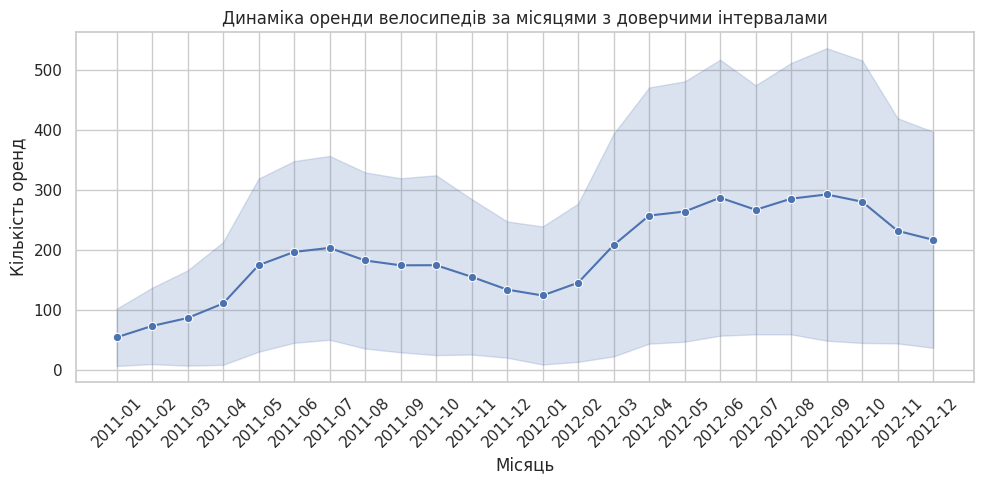

In [16]:
plt.figure(figsize=(10, 5))
sns.lineplot(df, x='month_year', y='count', errorbar='sd', marker='o')
plt.title('Динаміка оренди велосипедів за місяцями з доверчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренд')
plt.xticks(rotation=45)
plt.tight_layout();

В період з травня по вересень 2012 року спостерігається найбільша невизначенність і розкид у даних за весь представлений час. Відстань від нижньої межі (близько 50) до верхньої межі (понад 500) є максимальною саме в ці місяці.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

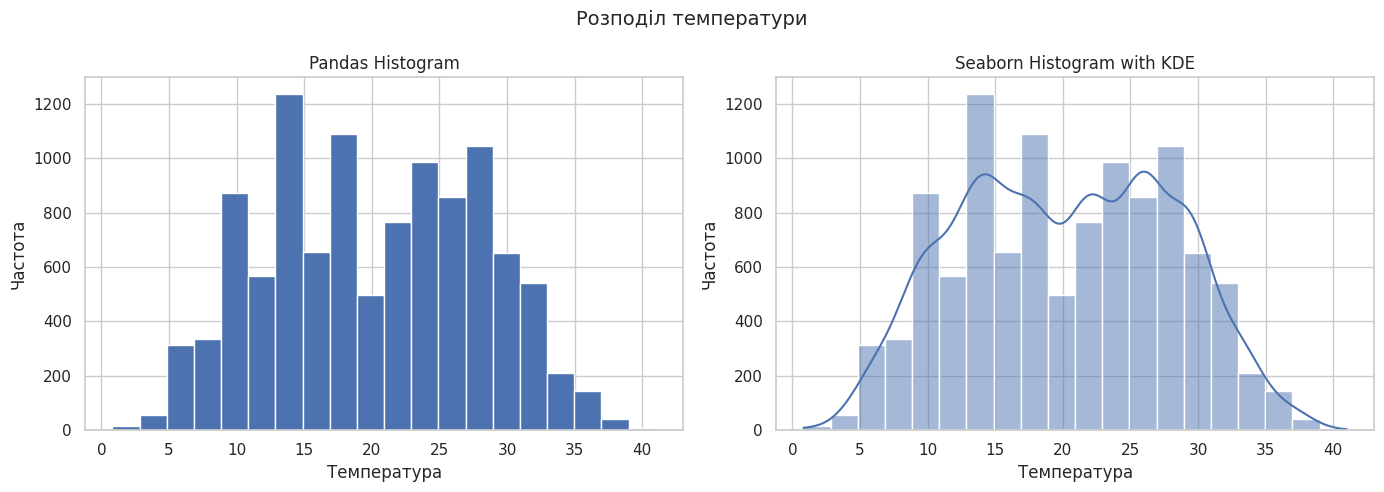

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bins_count = 20

# 1. Гістограма Pandas
df['temp'].plot(kind='hist', bins=bins_count, ax=axes[0], title='Pandas Histogram')
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

# 2. Гістограма Seaborn з kde=True
sns.histplot(df['temp'], bins=bins_count, kde=True, ax=axes[1])
axes[1].set_title('Seaborn Histogram with KDE')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

fig.suptitle('Розподіл температури', fontsize=14)
plt.tight_layout()
plt.show()

1. За замовчуванням Pandas має більш базовий і строгий вигляд та базову колірну гаму. Seaborn автоматично застосовує більш естетичний стиль (м'які кольори, чіткі межі стовпчиків) і надає зручні параметри для згладжування даних.
2. KDE(Kernel Density Estimate) — ядерна оцінка щільності розподілу. Це плавна крива лінія, яка «згладжує» гістограму. Вона допомагає побачити, де знаходяться основні піки, не прив'язуючись до конкретної ширини стовпчиків (бінів).

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

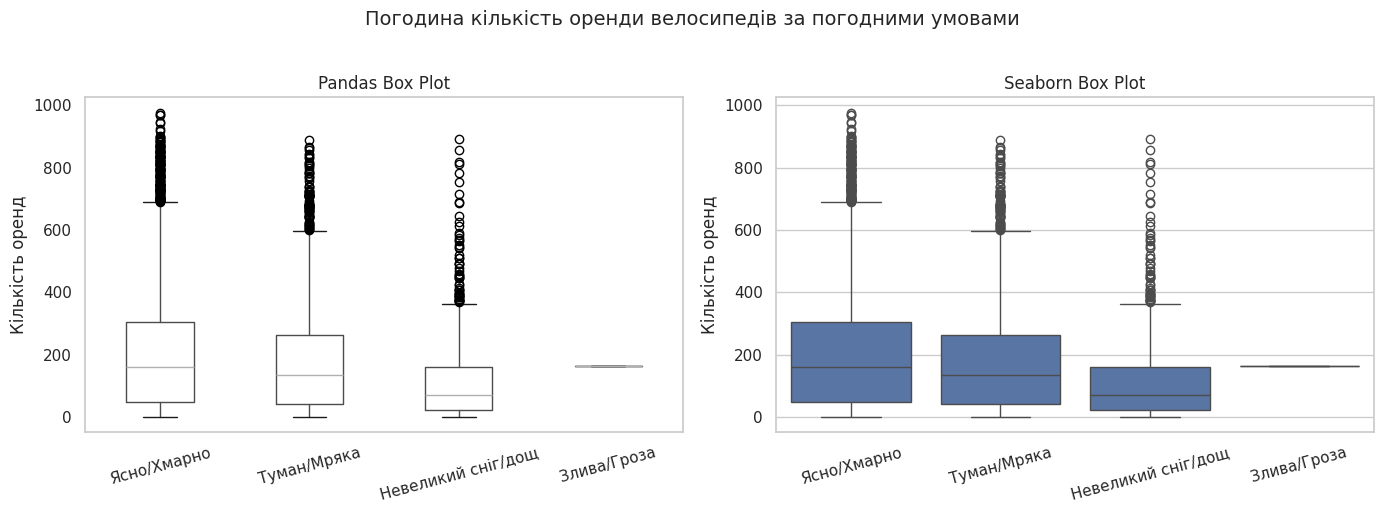

In [23]:
weather_labels = {1: 'Ясно/Хмарно', 2: 'Туман/Мряка', 3: 'Невеликий сніг/дощ', 4: 'Злива/Гроза'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box Plot Pandas
df.boxplot(column='count', by='weather', grid=False, ax=axes[0])
axes[0].set_title('Pandas Box Plot')
axes[0].set_ylabel('Кількість оренд')
axes[0].set_xlabel('')
axes[0].set_xticks(range(1, len(weather_labels) + 1))
axes[0].set_xticklabels([weather_labels.get(i, i) for i in sorted(df['weather'].unique())], rotation=15)

# 2. Box Plot Seaborn
sns.boxplot(data=df, x='weather', y='count', ax=axes[1])
axes[1].set_title('Seaborn Box Plot')
axes[1].set_ylabel('Кількість оренд')
axes[1].set_xlabel('')
axes[1].set_xticks(range(len(weather_labels)))
axes[1].set_xticklabels([weather_labels.get(i, i) for i in sorted(df['weather'].unique())], rotation=15)

plt.suptitle('Погодина кількість оренди велосипедів за погодними умовами', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

З графіків видно відчутну різницю: в Pandas графік стандартний без додаткових форматувань, в той час box plot Seaborn вже за замовчуванням з кольором та градієнтою сіткою. Також Pandas при виклику by='weather' автоматично додає зверху системний заголовок "Boxplot grouped by weather", який накладається на заголовок фігури та вимагає видалення, Seaborn робить це чистіше. У Pandas викиди малюються великими чорними колами, які зливаються в суцільні лінії. У Seaborn ці точки виглядають більш акуратно й узгоджуються з колірною гамою.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


In [19]:
correlation = df[['count', 'temp', 'atemp', 'humidity', 'windspeed' ]].corr()

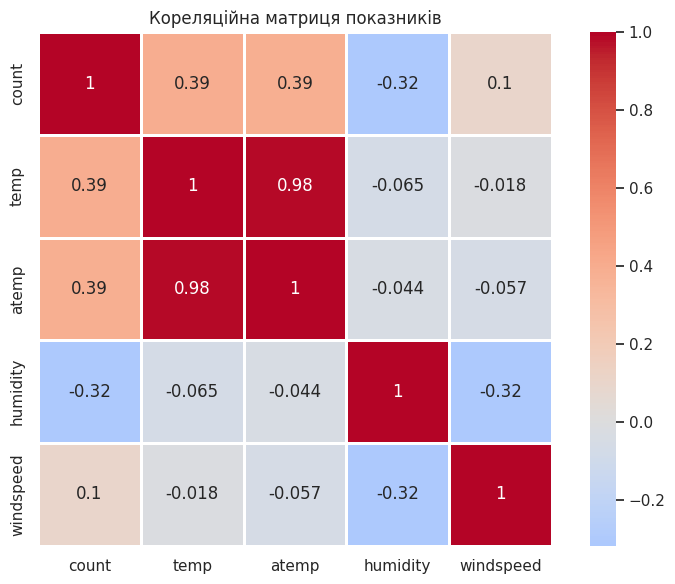

In [20]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1
            )

plt.title('Кореляційна матриця показників')
plt.tight_layout()
plt.show()

1. Згідно побудованної матриці найсильніше корелюють з загальною кількістю оренди: швидкість вітру та вологість. Вони мають негативну кореляцію -0.32. Це можна пояснити тим, що у несприятливу погоду (наприклад в дощ чи сільний вітер) оренда велосипедів зменшується.
Найсильніша позитивна кореляція 0,39 температура(як відчувається) - загальна оренда, навпаки показує збільшення оренди велосипедів
2. Кореляція між температурою в градусах та температурою, яка відчувається дорівнює 0.98(майже дорівнює 1). Це можна пояснити тим, що температура відчувається достатньо вірно згідно даних які маємо.
3. Змінні, які мають негативну кореляцію: загальна оренда - вологість, вологість - сильний вітер. Цей показник дорівнює -0.32 і він найбільший серед інших. Трохи нижчі показники, але також негативні мають температура (та як відчувається) - вологість та температура (та як відчувається) - сильний вітер.

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


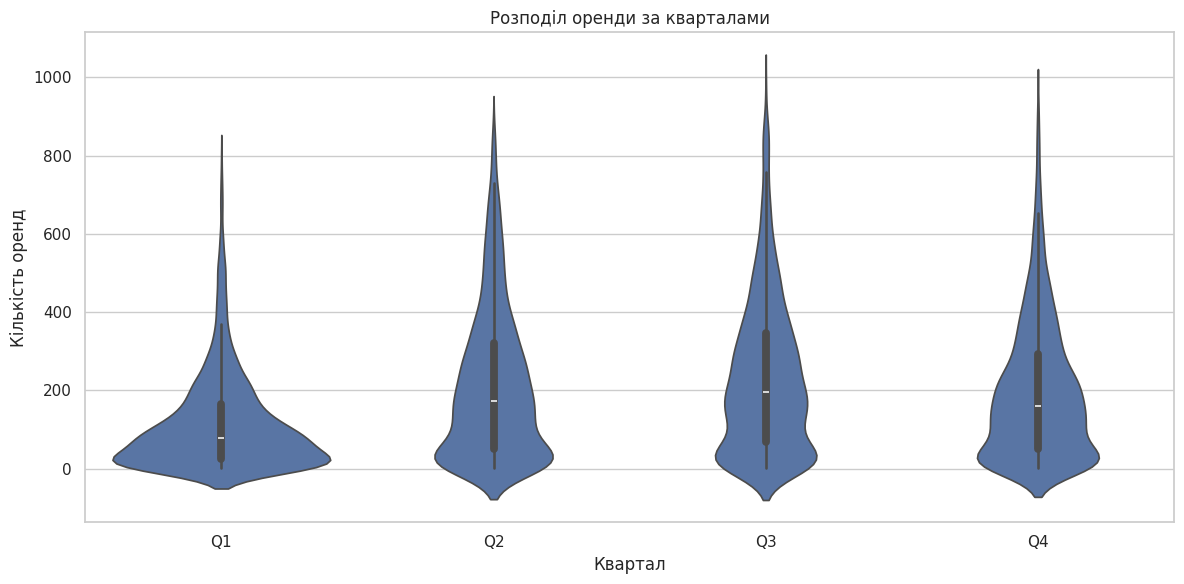

In [24]:
df['season_label'] = df['season'].map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'})

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='season_label',
    y='count',
    order=['Q1', 'Q2', 'Q3', 'Q4']
)
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.title('Розподіл оренди за кварталами')
plt.tight_layout()
plt.show()

1. Товщина violin plot відображає щільність розподілу даних. Чим ширший графік на певній висоті, тим частіше трапляється саме така кількість оренд. Звуження показують рідкісні значення. На прикладі першого кварталу, бачимо щільність розподілу даних біля 0 до 100. Це означає, що більшість днів у першому кварталі мають мінімальну кількість оренд.
2. Найбільша варіабельність оренд спостерігається в 3 кварталі, "скрипка" є найвищою і простягається від 0 майже до більше 1000 оренд. Це свідчить про найбільший розмах і розсіювання даних (від спокійних днів до рекордно високих піків).
3. Violin plot додатково показує повний симетричний графік щільності, дозволяючи побачити реальні піки, «брюшка» та мультимодальність, які приховані всередині прямокутника Box plot.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

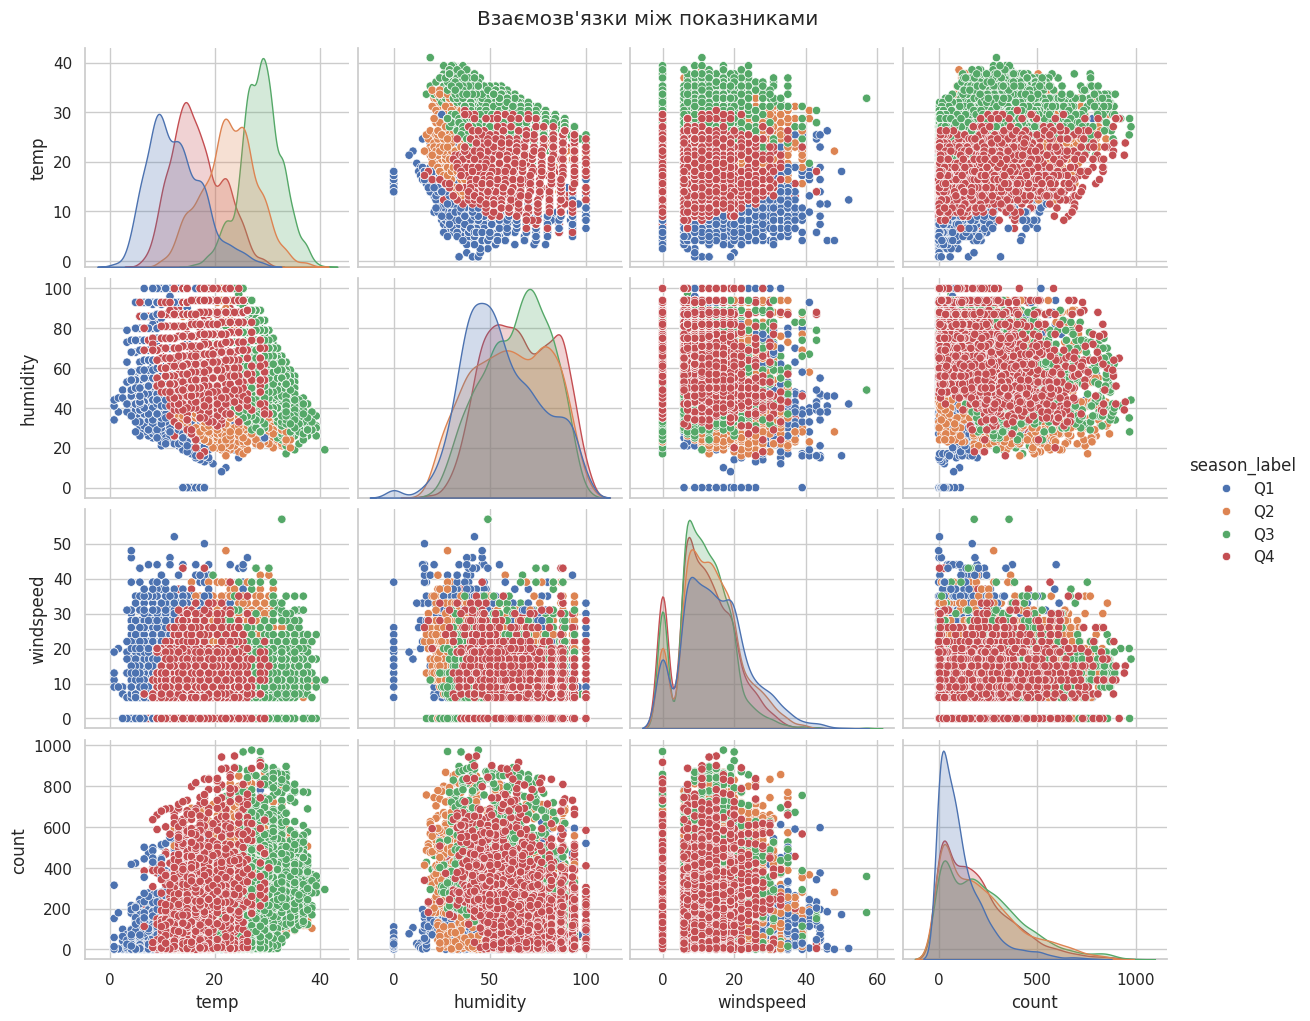

In [11]:
sample_df = df[['temp', 'humidity', 'windspeed', 'count', 'season_label']]
sns.pairplot(sample_df, hue='season_label', height=2.5, aspect=1.2)
plt.suptitle("Взаємозв'язки між показниками", y=1.02)
plt.show()
plt.show()

1. Між температурою та кількостю оренд спостерігається найсильніший лінійний зв'язок. На графіку на перетині цих двох змін видно вихідний тренд знизу наліво вгору направо. Зі зростанням температури максимальна кількість оренд стрімко підвищується.
Також спостерігається зворотний тренд між вологістю та кількостю оренд: при дуже високій вологості (близько 100%) щільність оренд падає практично до нуля.
2. Найбільше відрізняється між кварталами - це температура. Перший квартал (синій): повністю зміщений вліво (найнижчі температури). Третій квартал (зелений): знаходиться вкрай праворуч (найвищі температури).Та другий і четвертий квартал(відповідно помаранчевий і червоний): займають проміжне становище.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

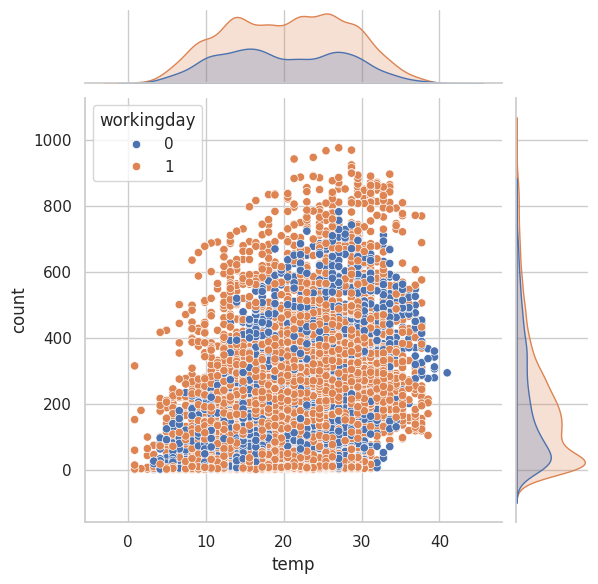

In [12]:
depend = df[['temp', 'count', 'workingday']]
sns.jointplot(data=depend, x='temp', y='count', hue='workingday');

1. Розподіл температури (верхній графік) показує частоту спостережень для різних рівнів температури. Графіки для робочих та вихідних днів майже повністю дублюють один одного за формою та висотою, тобто температурний режим розподілений абсолютно однаково незалежно від типу дня. Погодні умови не мають системного зсуву в бік вихідних чи робочих днів.
Розподіл кількості оренд (нижній графік) показує щільність розподілу обсягів оренд від 0 до 1000 і більше одиниць. Обидва розподіли мають виражену асиметрію праворуч, де найвища щільність даних згрупована в діапазоні від 0 до 200 оренд. Основна маса вимірів за годину припадає на відносно низький попит. Проте саме в робочі дні генеруються екстремально високі піки оренд.

2. Різниця у поведінці користувачів у робочий і неробочий день:
- за температурою графіки розподілу робочих та неробочих днів майже ідентично накладаються один на одного, це логічно, адже погода розподіляється рівномірно незалежно від дня тижня;
- за кількістю оренд у робочі дні (помаранчеві точки) спостерігається значно більша кількість максимальних піків (значення досягають 800–1000 оренд), це зумовлено регулярними поїздками на роботу та навчання у пікові години;
у неробочі дні (сині точки) попит є більш помірним і збалансованим, рідко перевищуючи 600–700 оренд на годину (прогулянковий формат).